In [37]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
import time
import random


def thomas_inplace(a, b, c, d):
    n = len(d)
    for i in range(1, n):
        w = b[i - 1] / a[i - 1]
        a[i] -= w * c[i - 1]
        d[i] -= w * d[i - 1]

    x = np.empty(n, dtype=d.dtype)
    x[-1] = d[-1] / a[-1]
    for i in range(n - 2, -1, -1):
        x[i] = (d[i] - c[i] * x[i + 1]) / a[i]
        
    return x

In [15]:
real_x = np.array([1 if random.randint(1, 10) % 2 == 0 else -1 for _ in range(1001)])

In [35]:
from numpy.linalg import inv

def forward_elimination(A, b,dtype):
    A = A.astype(dtype)
    b = b.astype(dtype)
    n = len(b)
    
    for k in range(n):
        max_row = np.argmax(np.abs(A[k:, k])) + k
        A[[k, max_row]] = A[[max_row, k]]
        b[[k, max_row]] = b[[max_row, k]]
        
        for i in range(k + 1, n):
            factor = A[i, k] / A[k, k]
            A[i, k:] -= factor * A[k, k:]
            b[i] -= factor * b[k]

    return A, b

def back_substitution(A, b, dtype):
    n = len(b)
    x = np.zeros(n,dtype=dtype)
    for i in reversed(range(n)):
        x[i] = (b[i] - np.dot(A[i, i + 1:], x[i + 1:])) / A[i, i]
    return x

def gauss_solve(A, b,dtype):
    A, b = forward_elimination(A, b,dtype)
    return back_substitution(A, b,dtype)

def gauss(A, b,dtype):
    x = gauss_solve(A, b,dtype)
    return x

def gaus_zadanie_2(n, real_x, dtype):
    k = 4
    m = 5
    A = np.zeros((n, n), dtype=dtype)
    for i in range(n):
        for j in range(n):
            if j == i:
                A[i, i] = k 
            elif j == i + 1:
                A[i, j] = 1/(m+i)
            elif j == i - 1 and i > 0:
                A[i, j] = k/(i+m+1)
            else:
                A[i, j] = 0 
    b = A @ real_x
    start_time = time.perf_counter()
    x = gauss(A,b,dtype)
    end_time = time.perf_counter()
    return f" n: {n}, błąd maksymlany: {np.max(abs(x-real_x))}, czas: {end_time - start_time}, pamieć: {A.nbytes} "

In [36]:
for i in [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,30,40,50,100,200,300,400,500,600,700,800,900,1000]:
    print("float32")
    print(gaus_zadanie_2(i, real_x[:i], dtype=np.float32))
    print("float64")
    print(gaus_zadanie_2(i, real_x[:i], dtype=np.float64))
    print("-------------------------")


float32
 n: 2, błąd maksymlany: 1.1920928955078125e-07, czas: 0.0014913140003045555, pamieć: 16 
float64
 n: 2, błąd maksymlany: 1.1102230246251565e-16, czas: 0.00012858499940193724, pamieć: 32 
-------------------------
float32
 n: 3, błąd maksymlany: 5.960464477539063e-08, czas: 0.0003458909995970316, pamieć: 36 
float64
 n: 3, błąd maksymlany: 0.0, czas: 8.793300003162585e-05, pamieć: 72 
-------------------------
float32
 n: 4, błąd maksymlany: 5.960464477539063e-08, czas: 7.543699939560611e-05, pamieć: 64 
float64
 n: 4, błąd maksymlany: 2.220446049250313e-16, czas: 4.950800030201208e-05, pamieć: 128 
-------------------------
float32
 n: 5, błąd maksymlany: 1.1920928955078125e-07, czas: 9.119499918597285e-05, pamieć: 100 
float64
 n: 5, błąd maksymlany: 2.220446049250313e-16, czas: 6.287799988058396e-05, pamieć: 200 
-------------------------
float32
 n: 6, błąd maksymlany: 1.1920928955078125e-07, czas: 7.801300125720445e-05, pamieć: 144 
float64
 n: 6, błąd maksymlany: 2.2204460

In [33]:
def prepare_tridiagonal_system(x, n, k, m, dtype):
    a = np.full(n, k, dtype=dtype)                     
    b = np.zeros(n - 1, dtype=dtype)                   
    c = np.zeros(n - 1, dtype=dtype)                  
    d = np.random.rand(n).astype(dtype)                

    for i in range(n - 1):
        c[i] = 1 / (m + i)                             
        b[i] = k / (i + m + 2)                          

    return a, b, c, d


def compute_rhs_from_solution(x, a, b, c,dtype):
    n = len(x)
    d = np.zeros(n, dtype= dtype)

    for i in range(n):
        d[i] = a[i] * x[i]
        if i > 0:
            d[i] += b[i - 1] * x[i - 1]  
        if i < n - 1:
            d[i] += c[i] * x[i + 1]      

    return d

def thomas_zadanie(n,real_x,dtype):
    k = 4
    m = 5
    a, b, c, _ = prepare_tridiagonal_system(real_x, n, k, m, dtype)
    d = compute_rhs_from_solution(real_x, a, b, c,dtype)
    start_time = time.perf_counter()
    x = thomas_inplace(a.copy(), b.copy(), c.copy(), d.copy())
    end_time = time.perf_counter()
    return f" n: {n}, błąd maksymlany: {np.max(abs(x-real_x))}, czas: {end_time - start_time}, pamieć: {a.nbytes + b.nbytes + c.nbytes}"


In [34]:
for i in [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,30,40,50,100,200,300,400,500,600,700,800,900,1000]:
    print("float32")
    print(thomas_zadanie(i, real_x[:i], dtype=np.float32))
    print("float64")
    print(thomas_zadanie(i, real_x[:i], dtype=np.float64))
    print("-------------------------")

float32
 n: 2, błąd maksymlany: 1.1920928955078125e-07, czas: 0.0004776620007760357, pamieć: 16
float64
 n: 2, błąd maksymlany: 1.1102230246251565e-16, czas: 0.00025160200129903387, pamieć: 32
-------------------------
float32
 n: 3, błąd maksymlany: 1.1920928955078125e-07, czas: 1.9859999156324193e-05, pamieć: 28
float64
 n: 3, błąd maksymlany: 2.220446049250313e-16, czas: 1.805099964258261e-05, pamieć: 56
-------------------------
float32
 n: 4, błąd maksymlany: 1.1920928955078125e-07, czas: 1.871599852165673e-05, pamieć: 40
float64
 n: 4, błąd maksymlany: 2.220446049250313e-16, czas: 0.00018893599917646497, pamieć: 80
-------------------------
float32
 n: 5, błąd maksymlany: 1.1920928955078125e-07, czas: 2.5973000447265804e-05, pamieć: 52
float64
 n: 5, błąd maksymlany: 2.220446049250313e-16, czas: 3.977800042775925e-05, pamieć: 104
-------------------------
float32
 n: 6, błąd maksymlany: 1.1920928955078125e-07, czas: 3.2023001040215604e-05, pamieć: 64
float64
 n: 6, błąd maksymlan

In [50]:
def gauss_system(n, real_x, dtype):
    k = 4
    m = 5
    A = np.zeros((n, n), dtype=dtype)
    for i in range(n):
        for j in range(n):
            if j == i:
                A[i, j] = k
            elif j == i + 1:
                A[i, j] = 1 / (m + i)
            elif j == i - 1 and i > 0:
                A[i, j] = k / (i + m + 1)
    b = A @ real_x
    start_time = time.perf_counter()
    x = gauss(A, b, dtype)
    end_time = time.perf_counter()
    return np.max(np.abs(x - real_x)), end_time - start_time, A.nbytes
def prepare_tridiagonal_system(n, k, m, dtype):
    a = np.full(n, k, dtype=dtype)
    b = np.zeros(n - 1, dtype=dtype)
    c = np.zeros(n - 1, dtype=dtype)
    for i in range(n - 1):
        c[i] = 1 / (m + i)
        b[i] = k / (i + m + 2)
    return a, b, c

def compute_rhs(real_x, a, b, c, dtype):
    n = len(real_x)
    d = np.zeros(n, dtype=dtype)
    for i in range(n):
        d[i] = a[i] * real_x[i]
        if i > 0:
            d[i] += b[i - 1] * real_x[i - 1]
        if i < n - 1:
            d[i] += c[i] * real_x[i + 1]
    return d

def thomas_system(n, real_x, dtype):
    k = 4
    m = 5
    a, b, c = prepare_tridiagonal_system(n, k, m, dtype)
    d = compute_rhs(real_x, a, b, c, dtype)
    start_time = time.perf_counter()
    x = thomas_inplace(a.copy(), b.copy(), c.copy(), d.copy())
    end_time = time.perf_counter()
    return np.max(np.abs(x - real_x)), end_time - start_time, a.nbytes + b.nbytes + c.nbytes
import matplotlib.pyplot as plt

ns = list(range(2, 1001, 20))

def collect_data(dtype1, dtype2):
    gauss32_time, gauss64_time = [], []
    thomas32_time, thomas64_time = [], []
    gauss64_mem, thomas64_mem = [], []

    for n in ns:
        r_x = real_x[:n]

        _, t_g32, _ = gauss_system(n, r_x, dtype1)
        _, t_g64, mem_g64 = gauss_system(n, r_x, dtype2)

        _, t_t32, _ = thomas_system(n, r_x, dtype1)
        _, t_t64, mem_t64 = thomas_system(n, r_x, dtype2)

        gauss32_time.append(t_g32)
        gauss64_time.append(t_g64)
        thomas32_time.append(t_t32)
        thomas64_time.append(t_t64)
        gauss64_mem.append(mem_g64)
        thomas64_mem.append(mem_t64)

    return gauss32_time, gauss64_time, thomas32_time, thomas64_time, gauss64_mem, thomas64_mem

g32, g64, t32, t64, gm64, tm64 = collect_data(np.float32, np.float64)



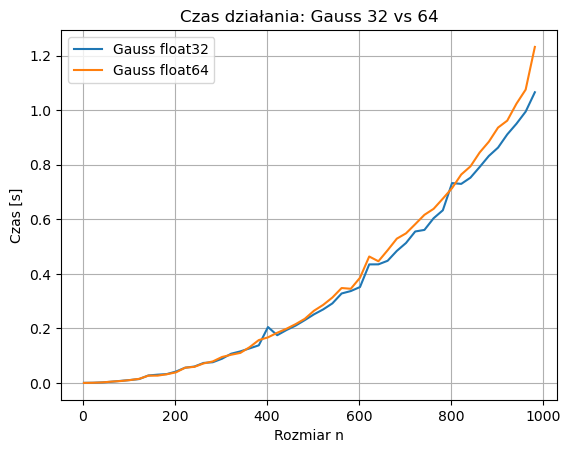

In [51]:
plt.plot(ns, g32, label='Gauss float32')
plt.plot(ns, g64, label='Gauss float64')
plt.xlabel("Rozmiar n")
plt.ylabel("Czas [s]")
plt.title("Czas działania: Gauss 32 vs 64")
plt.legend()
plt.grid(True)
plt.show()


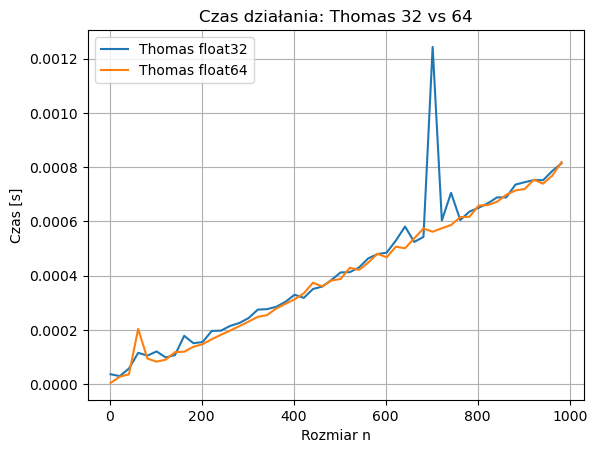

In [52]:
plt.plot(ns, t32, label='Thomas float32')
plt.plot(ns, t64, label='Thomas float64')
plt.xlabel("Rozmiar n")
plt.ylabel("Czas [s]")
plt.title("Czas działania: Thomas 32 vs 64")
plt.legend()
plt.grid(True)
plt.show()


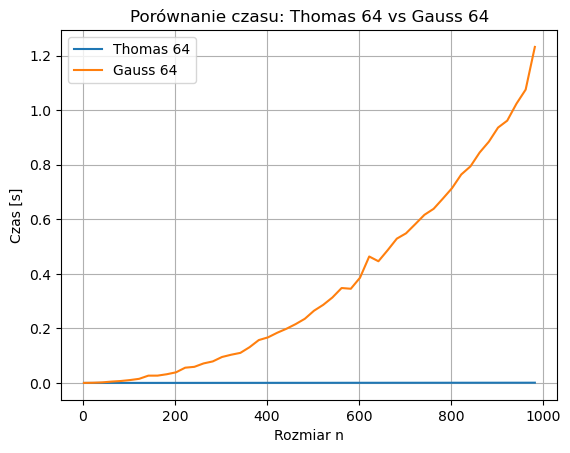

In [53]:
plt.plot(ns, t64, label='Thomas 64')
plt.plot(ns, g64, label='Gauss 64')
plt.xlabel("Rozmiar n")
plt.ylabel("Czas [s]")
plt.title("Porównanie czasu: Thomas 64 vs Gauss 64")
plt.legend()
plt.grid(True)
plt.show()


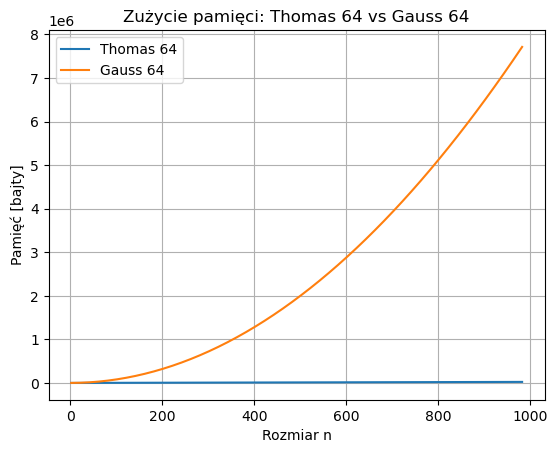

In [54]:
plt.plot(ns, tm64, label='Thomas 64')
plt.plot(ns, gm64, label='Gauss 64')
plt.xlabel("Rozmiar n")
plt.ylabel("Pamięć [bajty]")
plt.title("Zużycie pamięci: Thomas 64 vs Gauss 64")
plt.legend()
plt.grid(True)
plt.show()
